In [21]:
import pandas as pd
import cartopy.crs as ccrs
import matplotlib.path as mpath
import matplotlib.pyplot as plt
import numpy as np
import scipy.signal as signal
import xarray as xr
import glob
import om4labs.om4common as om4
import cftime
import momlevel as ml

# parameters for setting circular cutoff for Southern Ocean plots
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)

out_path_fig = '/work/Katherine.Turner/stormtrack_variability/figures/'
out_path_data = '/work/Katherine.Turner/smaller_projects/hifreq-variability/data/'

In [2]:
model = 'ESM4'

In [5]:
ds = xr.open_dataset(
    f"/work/Katherine.Turner/stormtrack_variability/data/{model}_cmip_monthly_storms.nc",
    use_cftime=True,
)

storms_seasonal = ds.center_counts.resample(time="QS-DEC").sum()

idx_jja = storms_seasonal.time.dt.month == 6
idx_djf = storms_seasonal.time.dt.month == 12

storms_djf = (
    storms_seasonal[idx_djf][1:-1] - storms_seasonal[idx_djf][1:-1].mean()
) / storms_seasonal[idx_djf][1:-1].std()
storms_jja = (
    storms_seasonal[idx_jja] - storms_seasonal[idx_jja].mean()
) / storms_seasonal[idx_jja].std()

STV = {}
STV["DJF"] = storms_djf
STV["JJA"] = storms_jja

low_storms = {}
high_storms = {}

low_storms["DJF"] = storms_djf.sortby(storms_djf).time[:50]
high_storms["DJF"] = storms_djf.sortby(storms_djf).time[-50:]

low_storms["JJA"] = storms_jja.sortby(storms_jja).time[:50]
high_storms["JJA"] = storms_jja.sortby(storms_jja).time[-50:]

In [35]:
var = 'precip'
comp = {'tau_x': 'atmos',
        'omldamax': 'ocean_monthly',
        'tos': 'ocean_monthly',
       'sos': 'ocean_monthly',
       'hfds': 'ocean_monthly',
       'precip': 'atmos'}

ds_v = xr.open_mfdataset(
        f"/work/Katherine.Turner/tempest-extremes/{model}_cmip/data/{comp[var]}*.{var}.nc",
        use_cftime=True,
    )

da_v_s = ds_v[var].resample(time="QS-DEC").sum()

da = {}

da["DJF"] = (da_v_s[4:-4:4, :, :] / 3).compute()
da["JJA"] = (da_v_s[2::4, :, :] / 3).compute()

In [36]:
season = ['DJF', 'JJA']
idx_high = {}
idx_low = {}
diff = {}

for s in season:
    idx_high[s] = da[s].time.dt.year.isin(high_storms[s].dt.year)
    idx_low[s] = da[s].time.dt.year.isin(low_storms[s].dt.year)
    
    diff[s] = da[s][idx_high[s], :, :].mean(dim="time") - da[s][idx_low[s], :, :].mean(dim="time")

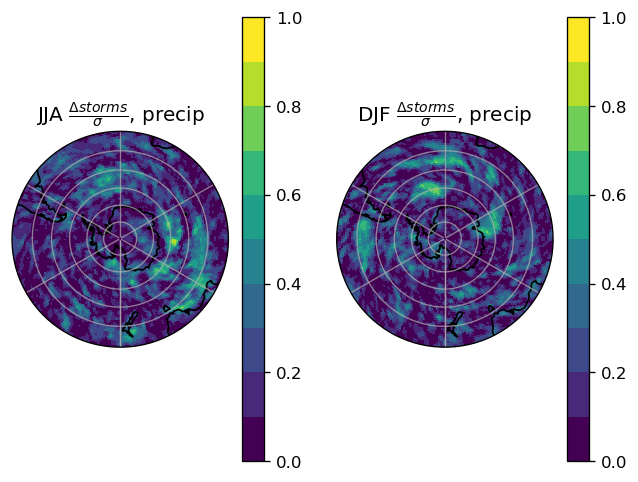

In [37]:
fig, axs = plt.subplots(
    nrows=1,
    ncols=2,
    dpi=120,
    subplot_kw={"projection": ccrs.SouthPolarStereo()},
)
axs = axs.flatten()

(np.abs(diff['JJA']) / da["JJA"].std(dim='time')).plot(
    ax=axs[0],
    x="lon",
    y="lat",
    vmax=1, vmin=0, extend='neither',
    cmap=plt.get_cmap('viridis', 10),
    transform=ccrs.PlateCarree(),
    cbar_kwargs={"label": ""},
    robust=True,
    #add_colorbar=False,
)

(np.abs(diff['DJF']) / da["DJF"].std(dim='time')).plot(
    ax=axs[1],
    x="lon",
    y="lat",
    vmax=1, vmin=0, extend='neither',
    cmap=plt.get_cmap('viridis', 10),
    transform=ccrs.PlateCarree(),
    cbar_kwargs={"label": ""},
    robust=True,
    #add_colorbar=False,
)


for i in range(2):
    axs[i].set_ylabel("")
    axs[i].set_xlabel("")
    axs[i].set_extent([-180, 180, -90, -30], ccrs.PlateCarree())
    axs[i].gridlines(alpha=0.7)
    axs[i].set_boundary(circle, transform=axs[i].transAxes)
    axs[i].coastlines()
    axs[0].set_title(rf'JJA $\frac{{\Delta storms}}{{\sigma}}$, {var}')
    axs[1].set_title(rf'DJF $\frac{{\Delta storms}}{{\sigma}}$, {var}')
    
plt.savefig(f"{out_path_fig}var_comp_{var}_{model}.png", format='png', dpi=100)

## interior fields

In [38]:
var = "so"
mode = "detrend"

ds_v = xr.open_mfdataset(
    f"/work/Katherine.Turner/tempest-extremes/{model}_cmip/data/*{var}.nc",
    use_cftime=True,
)

regions = {
    "e_pac": slice(360 - 180, 360 - 100),
    "e_ind": slice(120, 170),
    "w_ind": slice(60, 120),
}

da_v = ds_v[var].sel(lon=regions["e_pac"]).mean(dim="lon").compute()

In [39]:
da_v_s = da_v.resample(time="QS-DEC").sum()

da = {}
temp_1 = (da_v_s[4:-4:4, :, :] / 3).compute()
temp_2 = (da_v_s[2::4, :, :] / 3).compute()

da["DJF"] = ml.trend.linear_detrend(temp_1, mode="correct")
da["JJA"] = ml.trend.linear_detrend(temp_2, mode="correct")


season = ['DJF', 'JJA']
idx_high = {}
idx_low = {}
diff = {}

for s in season:
    idx_high[s] = da[s].time.dt.year.isin(high_storms[s].dt.year)
    idx_low[s] = da[s].time.dt.year.isin(low_storms[s].dt.year)
    
    diff[s] = da[s][idx_high[s], :, :].mean(dim="time") - da[s][idx_low[s], :, :].mean(dim="time")

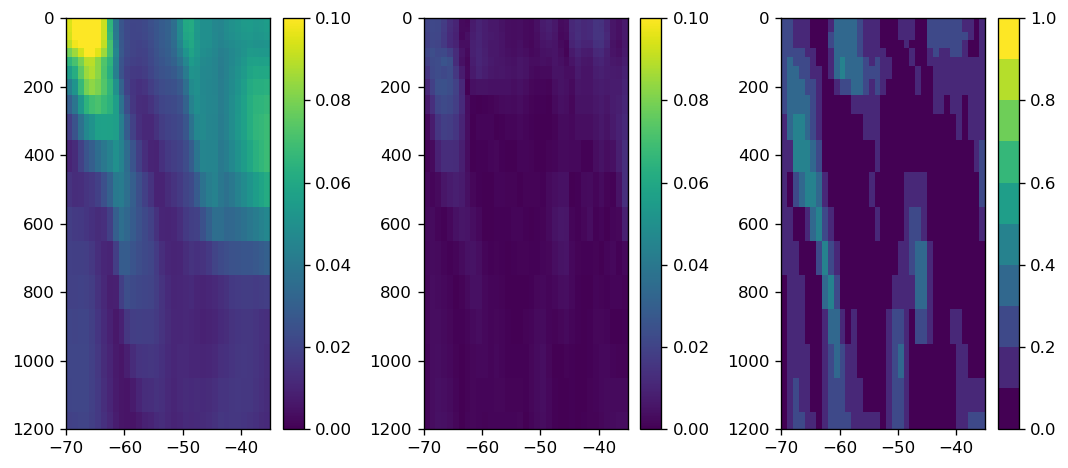

In [50]:
fig, axs = plt.subplots(
    nrows=1,
    ncols=3,
    dpi=120,
    figsize=(9,4)
)
axs = axs.flatten()

da["JJA"].std(dim='time').plot(
    ax=axs[0],
    x="lat",
    vmax=.1, vmin=0, extend='neither',
    #cmap=plt.get_cmap('viridis', 10),
    cbar_kwargs={"label": ""},
    #robust=True,
    #add_colorbar=False,
)

np.abs(diff['JJA']).plot(
    ax=axs[1],
    x="lat",
    vmax=.1, vmin=0, extend='neither',
    #cmap=plt.get_cmap('viridis', 10),
    cbar_kwargs={"label": ""},
    #robust=True,
    #add_colorbar=False,
)

(np.abs(diff['JJA']) / da["JJA"].std(dim='time')).plot(
    ax=axs[2],
    x="lat",
    vmax=1, vmin=0, extend='neither',
    cmap=plt.get_cmap('viridis', 10),
    cbar_kwargs={"label": ""},
    #robust=True,
    #add_colorbar=False,
)

for i in range(3):
    axs[i].set_xlim([-70,-35])
    axs[i].set_ylim([1200, 0])
    axs[i].set_ylabel('')
    axs[i].set_xlabel('')
    
plt.tight_layout()

In [ ]:
for i in range(2):
    axs[i].set_ylabel("")
    axs[i].set_xlabel("")
    axs[i].set_extent([-180, 180, -90, -30], ccrs.PlateCarree())
    axs[i].gridlines(alpha=0.7)
    axs[i].set_boundary(circle, transform=axs[i].transAxes)
    axs[i].coastlines()